In [4]:
# моделирование линейной системы
# взаимодействующих друг с другом
# магнитных спинов

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt

# импорт из библиотеки scipy.optimize функции curve_fit
from scipy.optimize import curve_fit

In [5]:
# Ячейка № 2

# задание функции, возвращающей мгновенные значения:
# полной энергии системы;
# энергии демона;
# суммарного магнитного момента
# моделируемой системы
def Ising(N_Spin, J, h, E_finish, N_Trial):
    # N_Spin - число спинов системы
    # J - константа обменного взаимодействия
    # h - внешнее магнитное поле
    # E_Finish - конечная энергия системы
    # N_Trial - число независимых испытаний в методе Монте-Карло

    # инициализация начальной конфигурации спинов
    S = np.ones(N_Spin)

    # вычисление начального значения энергии системы
    E_System_Test = -(J + h) * N_Spin

    # вычисление начального значения энергии демона
    E_Demon_Test = 2 * J * int((E_finish - E_System_Test) / (2 * J))

    # инициализация массивов, используемых
    # для хранения мгновенных значений:
    # полной энергии системы (E_System);
    # энергии демона (E_Demon);
    # суммарного магнитного момента
    # моделируемой системы (Summry_Spin_Moment)
    E_System = np.zeros(N_Spin * N_Trial + 1)
    E_Demon = np.zeros(N_Spin * N_Trial + 1)
    Summary_Spin_Moment = np.zeros(N_Spin * N_Trial + 1)
    # сохранение начальных значений
    # полной энергии системы;
    # энергии демона;
    # суммарного магнитного момента
    # моделируемой системы (Summry_Spin_Moment)
    E_System[0] = E_System_Test
    E_Demon[0] = E_Demon_Test
    Summary_Spin_Moment[0] = N_Spin

    # реализация метода микроканонического ансамбля
    k = 0
    N_Accept = 0

    for i in range(1, N_Trial + 1):
        for j in range(N_Spin):
            # случайный выбор номера переворачиваемого спина
            I_Spin = int(random.uniform(0, N_Spin))
            # периодические граничные условия
            if I_Spin == 0:
                Left = S[N_Spin - 1]
            else:
                Left = S[I_Spin - 1]
            if I_Spin == N_Spin - 1:
                Right = S[0]
            else:
                Right = S[I_Spin + 1]
            # пробное изменение энергии спина
            D_E = 2 * S[I_Spin] * (-h + J * (Left + Right))
            if D_E <= E_Demon_Test:
                # изменение энергии спина принимается
                S[I_Spin] = -S[I_Spin]
                N_Accept = N_Accept + 1
                E_Demon_Test = E_Demon_Test - D_E
                E_System_Test = E_System_Test + D_E
            k = k + 1
            E_System[k] = E_System_Test
            E_Demon[k] = E_Demon_Test
            Summary_Spin_Moment[k] = np.sum(S)

    # вычисление среднего числа
    # принятых пробных изменений ориентации спина
    N_Accept = N_Accept / (N_Trial * N_Spin)

    return E_System, E_Demon, Summary_Spin_Moment, N_Accept


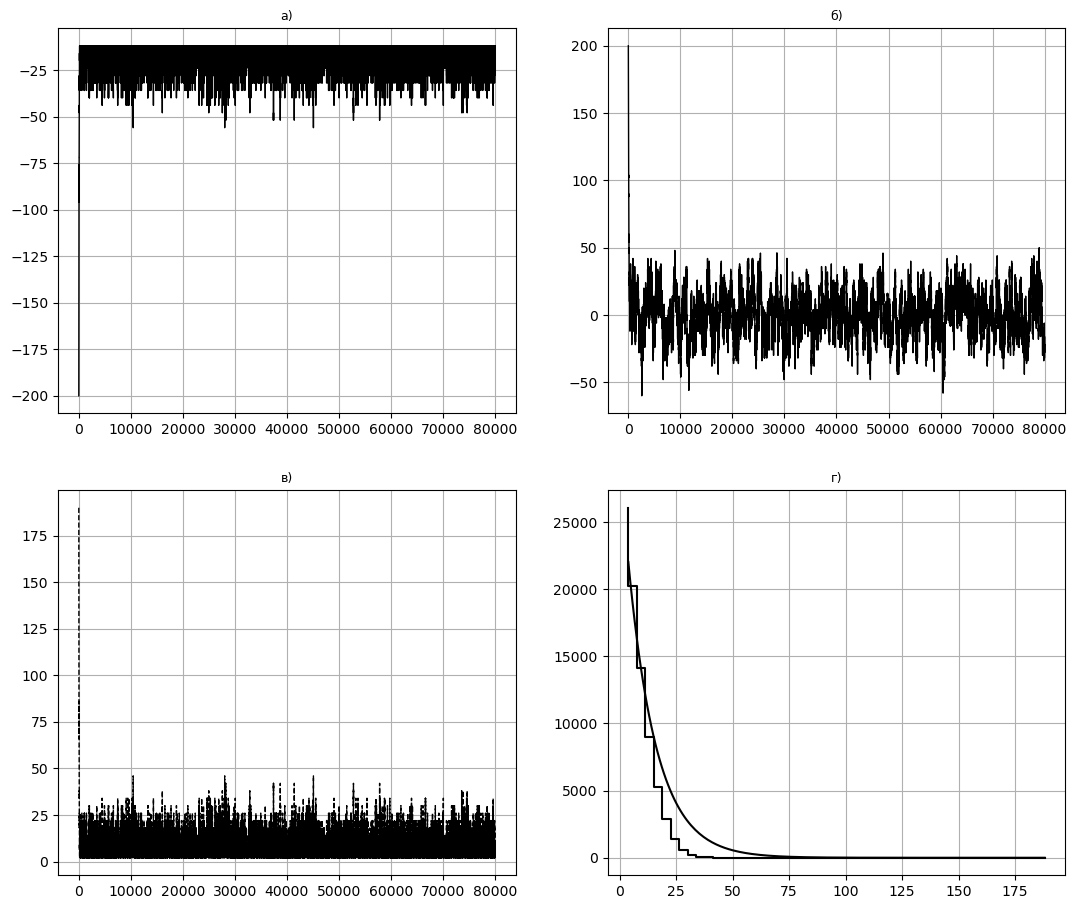

Mean_Spin=  0.0024767190410119873
Mean_E =  -0.09204759940500744
T =  9.3739874338615


In [ ]:
# Ячейка № 3

# вычисление и визуализация
# последовательностей, составленных из
# мгновенных значений энергий системы спинов,
# демона, суммарного магнитного момента
# системы спинов

# инициализация генератора случайных чисел
random.seed()

# задание числа спинов
N_Spin = 200

# задание значения спина
J = 1

# задание напряженности магнитного поля
h = 0

# задание конечного значения энергии
E_finish = -10

# задание числа испытаний метода Монте-Карло
N_Trial = 400

# вычисление последовательностей,
# составленных из мгновенных значений
# энергий системы спинов,
# демона, суммарного магнитного момента
# системы спинов
[E_System, E_Demon, Summary_Spin_Moment, N_Accept] = Ising(
    N_Spin, J, h, E_finish, N_Trial
)

# вычисление последовательностей,
# составленных из мгновенных значений
#  энергий системы спинов,
# демона, суммарного магнитного момента
# системы спинов
fig = plt.figure(figsize=(13, 11))

# визуализация последовательности,
# составленной из мгновенных значений
# энергии системы
ax = plt.subplot(2, 2, 1)
plt.plot(E_System, "-k", lw=1)
plt.grid(True)
ax.set_title("а)", fontsize=9)

# визуализация последовательностей,
# составленной из мгновенных значений
# полного магнитного момента системы
ax = plt.subplot(2, 2, 2)
plt.plot(Summary_Spin_Moment, "-k", lw=1)
plt.grid(True)
ax.set_title("б)", fontsize=9)

# визуализация последовательности,
# составленной из мгновенных значений
# энергии демона
ax = plt.subplot(2, 2, 3)
plt.plot(E_Demon, "--k", lw=1)
plt.grid(True)
ax.set_title("в)", fontsize=9)

# визуализация эмпирической плотности распределения
# последовательности, составленной из мгновенных значений
# энергии системы
ax = plt.subplot(2, 2, 4)

# вычисление и визуализация
# эмпирической плотности распределения
# последовательности, составленной
# из мгновенных значений энергии демона,
# и аппроксимации ее эмпирической плотности распределения
N_bin = 49
xbins = np.arange(
    np.min(E_Demon), np.max(E_Demon), (max(E_Demon) - min(E_Demon)) / N_bin
)

# вычисление эмпирической
# плотности распределения
# энергии демона
H = np.histogram(E_Demon, bins=50)

# вычисление координат
# центров интервалов гистограммы
x = np.zeros(len(H[1]) - 1)
for i in range(len(H[1]) - 1):
    x[i] = (H[1][i] + H[1][i + 1]) / 2


# вычисление коэффициентов a, b, c
# аппроксимации эмпирической
# плотности распределения
# мгновенной  энергии демона
# функцией вида a * sqrt(-b * x)
Coeff = curve_fit(lambda t, a, b: a * np.exp(-b * t), x, H[0], bounds=(0, [30000, 0.2]))
Сoeff2 = Coeff[0]


# задание функции, возвращающей
# значения аппроксимирующей функции
def func(x, a, b):
    return a * np.exp(-b * x)


# вычисление значений аппроксимирующей функции
x2 = np.linspace(x[0], x[len(x) - 1], 200)
y = func(x2, Сoeff2[0], Сoeff2[1])

# визуализация эмпирической плотности распределения
# аппроксимации функцией вида a * sqrt(-b * x)
ax = plt.subplot(2, 2, 4)
plt.step(x, H[0], color="black")
plt.plot(x2, y, "-k")
plt.grid(True)
ax.set_title("г)", fontsize=9)

plt.show()

# вычисление средней намагниченности на один спин
Mean_Spin = np.mean(Summary_Spin_Moment) / N_Spin

# вычисление средней энергии на один спин
Mean_E = np.mean(E_System) / N_Spin

# вычисление температуры системы
T = 2 / np.log(1 + 2 / np.mean(E_Demon))

print("Mean_Spin= ", Mean_Spin)

print("Mean_E = ", Mean_E)

print("T = ", T)